# 03 · Logistics KPI Analysis

The core of the project: measure delivery, cost and fulfilment performance and find **where** the
supply chain under-performs.

Delivery KPIs are computed on non-cancelled orders only.

In [1]:
import sys
sys.path.append("../src")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

from config import CLEAN_ITEMS_PATH, CLEAN_ORDERS_PATH, IMAGES
from viz import set_style, label_bars, BLUE, ORANGE, AQUA, MUTED, TEXT_2

set_style()
pd.set_option("display.float_format", "{:,.2f}".format)
pd.set_option("display.max_columns", 40)

from kpis import headline_kpis, delivery_by, monthly_trend, abc_classification

items = pd.read_csv(CLEAN_ITEMS_PATH, parse_dates=["order_date", "shipping_date"])
orders = pd.read_csv(CLEAN_ORDERS_PATH, parse_dates=["order_date", "shipping_date"])

## 1. Headline KPIs

In [2]:
k = headline_kpis(orders)
pd.Series(k, name="value").to_frame()

,value
Total orders,"12,000.00"
Net sales,"3,917,549.72"
Profit,"433,010.42"
Profit margin %,11.05
On-time delivery %,42.60
Late delivery %,57.40
Avg actual lead time (days),3.55
Avg scheduled lead time (days),2.94
Avg delay when late (days),1.65
Cancellation / fraud %,6.40


## 2. Delivery performance by shipping mode

In [3]:
mode = delivery_by(orders, "shipping_mode")
mode

,orders,late_pct,on_time_pct,avg_scheduled_days,avg_actual_days,avg_delay_days,net_sales
shipping_mode,,,,,,,
First Class,1659,95.90,4.10,1.00,2.00,1.00,"545,201.93"
Second Class,2210,82.99,17.01,2.00,4.03,2.03,"718,711.66"
Same Day,627,47.69,52.31,0.00,0.49,0.49,"205,934.56"
Standard Class,6736,40.42,59.58,4.00,4.06,0.06,"2,196,010.04"


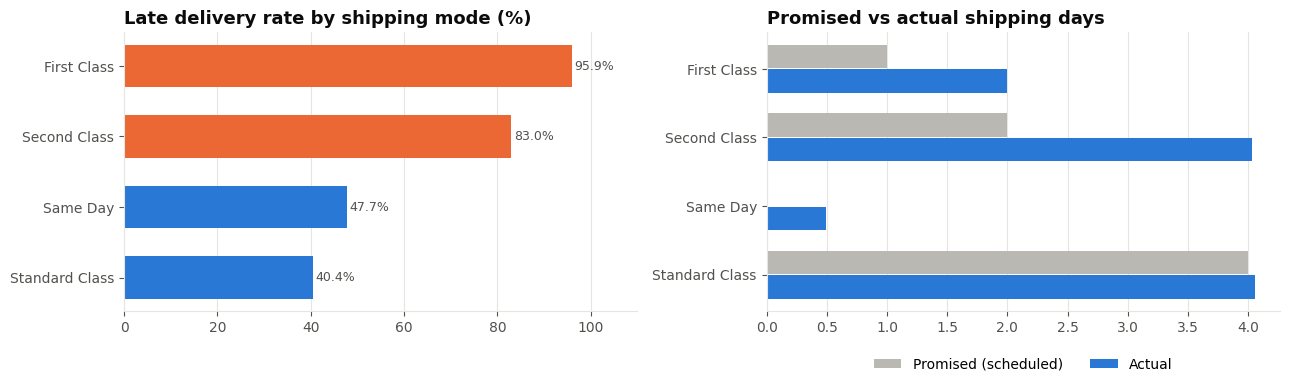

In [4]:
m = mode.sort_values("late_pct")
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].barh(m.index, m["late_pct"], color=[ORANGE if v > 60 else BLUE for v in m["late_pct"]], height=0.6)
axes[0].set_title("Late delivery rate by shipping mode (%)")
axes[0].set_xlim(0, 110)
axes[0].grid(axis="y", visible=False)
label_bars(axes[0])

y = np.arange(len(m))
axes[1].barh(y + 0.18, m["avg_scheduled_days"], height=0.34, color=MUTED, label="Promised (scheduled)")
axes[1].barh(y - 0.18, m["avg_actual_days"], height=0.34, color=BLUE, label="Actual")
axes[1].set_yticks(y, m.index)
axes[1].set_title("Promised vs actual shipping days")
axes[1].grid(axis="y", visible=False)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)
plt.tight_layout()
plt.savefig(IMAGES / "06_late_rate_by_mode.png")

**Insight:** First Class and Second Class are late in the vast majority of cases. The promise
(1 and 2 days) is shorter than what carriers actually achieve, so the problem is an
**unrealistic SLA**, not just slow shipping. Standard Class (4-day promise) performs best.

## 3. Regional performance

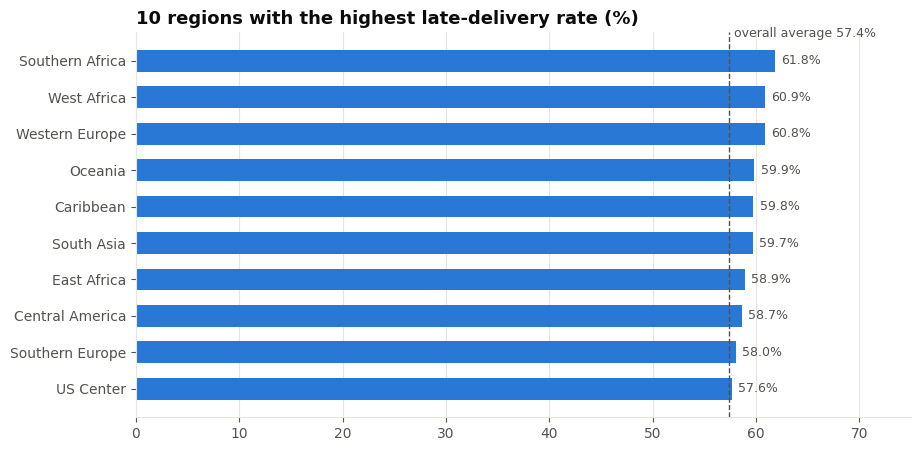

In [5]:
region = delivery_by(orders, "region")
top = region[region["orders"] >= 100].head(10).sort_values("late_pct")
overall = k["Late delivery %"]
fig, ax = plt.subplots(figsize=(10, 5))
ax.barh(top.index, top["late_pct"], color=BLUE, height=0.6)
ax.axvline(overall, color=TEXT_2, linestyle="--", linewidth=1)
ax.text(overall + 0.5, len(top) - 0.35, f"overall average {overall:.1f}%", color=TEXT_2, fontsize=9)
ax.set_xlim(0, 75)
ax.set_title("10 regions with the highest late-delivery rate (%)")
ax.grid(axis="y", visible=False)
label_bars(ax)
plt.savefig(IMAGES / "07_late_rate_by_region.png")

In [6]:
delivery_by(orders, "market")

,orders,late_pct,on_time_pct,avg_scheduled_days,avg_actual_days,avg_delay_days,net_sales
market,,,,,,,
Africa,659,59.33,40.67,2.87,3.59,0.72,"224,431.68"
LATAM,3244,58.20,41.80,2.94,3.59,0.66,"1,035,631.49"
Europe,3147,57.45,42.55,2.92,3.52,0.60,"1,040,133.49"
Pacific Asia,2614,56.92,43.08,2.96,3.55,0.59,"846,984.59"
USCA,1568,55.61,44.39,3.00,3.50,0.50,"518,676.94"


## 4. Monthly trend of late deliveries

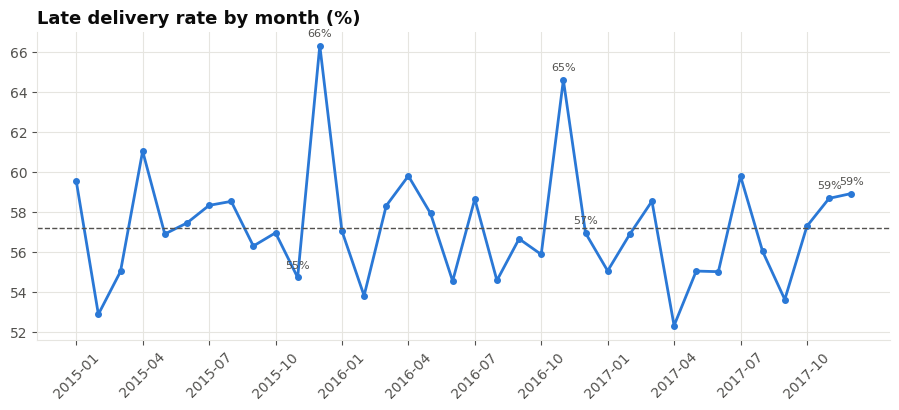

In [7]:
trend = monthly_trend(orders)
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(trend.index, trend["late_pct"], color=BLUE, marker="o", markersize=4)
ax.axhline(trend["late_pct"].mean(), color=TEXT_2, linestyle="--", linewidth=1)
ax.set_title("Late delivery rate by month (%)")
ax.set_xticks(trend.index[::3])
ax.tick_params(axis="x", rotation=45)
for i, (idx, row) in enumerate(trend.iterrows()):
    if idx.endswith(("-11", "-12")):
        ax.annotate(f"{row['late_pct']:.0f}%", (i, row["late_pct"]), xytext=(0, 7),
                    textcoords="offset points", ha="center", fontsize=8, color=TEXT_2)
plt.savefig(IMAGES / "08_monthly_late_trend.png")

In [8]:
peak = orders[orders["is_cancelled"] == 0].assign(peak=lambda d: d["order_date"].dt.month.isin([11, 12]))
peak.groupby(["shipping_mode", "peak"])["is_late"].mean().mul(100).unstack().rename(columns={False: "Jan-Oct", True: "Nov-Dec"}).round(1)

peak,Jan-Oct,Nov-Dec
shipping_mode,,
First Class,95.80,96.50
Same Day,47.70,47.50
Second Class,82.50,85.00
Standard Class,39.40,44.70


## 5. Order fulfilment, cancellations & fraud

In [9]:
status = orders["order_status"].value_counts(normalize=True).mul(100).round(2).rename("share_%")
status.to_frame()

,share_%
order_status,
COMPLETE,33.11
PENDING_PAYMENT,22.01
CLOSED,11.75
PENDING,11.14
PROCESSING,10.75
ON_HOLD,3.88
CANCELED,3.74
SUSPECTED_FRAUD,2.66
PAYMENT_REVIEW,0.96


In [10]:
fraud = orders.groupby("payment_type").agg(orders=("order_id", "count"),
                                           suspected_fraud_pct=("order_status", lambda s: 100 * (s == "SUSPECTED_FRAUD").mean()),
                                           cancelled_pct=("order_status", lambda s: 100 * (s == "CANCELED").mean()))
fraud.sort_values("suspected_fraud_pct", ascending=False).round(2)

,orders,suspected_fraud_pct,cancelled_pct
payment_type,,,
TRANSFER,3335,9.57,3.57
CASH,1297,0.00,3.55
DEBIT,4599,0.00,3.89
PAYMENT,2769,0.00,3.79


**Insight:** all suspected-fraud orders come through **TRANSFER** payments - a clear place to add payment verification.

## 6. Inventory prioritisation - ABC analysis

In [11]:
abc = abc_classification(items)
abc[["product", "category", "units", "net_sales", "revenue_share_%", "cumulative_%", "abc_class", "profit_margin_%"]]

,product,category,units,net_sales,revenue_share_%,cumulative_%,abc_class,profit_margin_%
0,Field & Stream Sportsman 16 Gun Fire Safe,Fishing,1160,"415,580.80",10.61,10.61,A,11.04
1,Nike Men's Free 5.0+ Running Shoe,Cardio Equipment,4406,"394,373.51",10.07,20.68,A,10.51
2,Perfect Fitness Perfect Rip Deck,Cleats,5132,"276,725.98",7.06,27.74,A,10.43
3,Dell Laptop,Computers,201,"270,975.00",6.92,34.66,A,11.09
4,Pelican Sunstream 100 Kayak,Water Sports,1469,"263,301.31",6.72,41.38,A,11.52
5,O'Brien Men's Neoprene Life Vest,Indoor/Outdoor Games,4758,"212,922.70",5.44,46.81,A,11.54
6,Nike Men's Dri-FIT Victory Golf Polo,Women's Apparel,4530,"202,622.50",5.17,51.98,A,10.58
7,Bowflex SelectTech 1090 Dumbbells,Fitness Accessories,370,"199,886.30",5.10,57.09,A,11.71
8,Nike Men's CJ Elite 2 TD Football Cleat,Men's Footwear,1708,"198,560.52",5.07,62.15,A,12.22
9,Garmin Forerunner 910XT GPS Watch,Electronics,595,"187,216.05",4.78,66.93,A,11.72


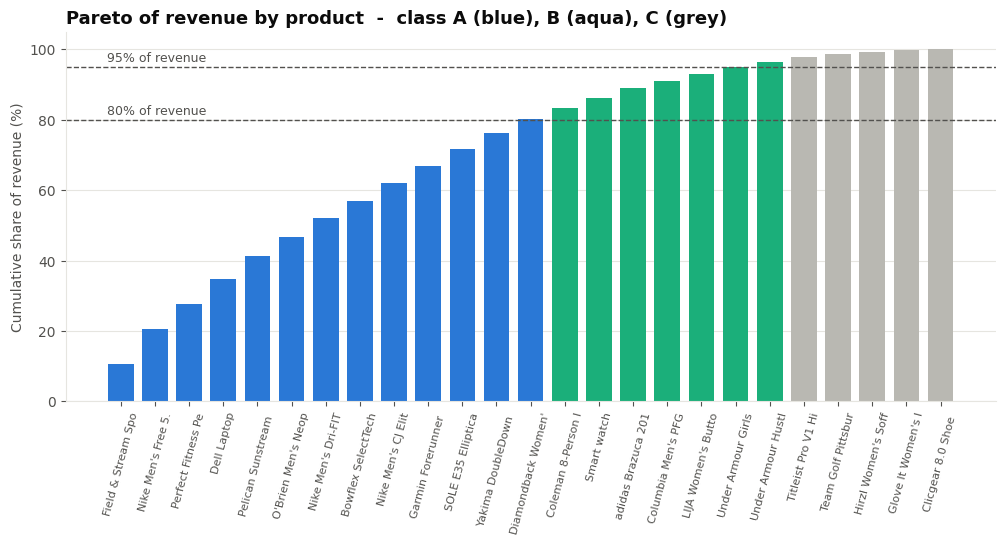

,products,revenue_share
abc_class,,
A,13,80.25
B,7,16.21
C,5,3.55


In [12]:
fig, ax = plt.subplots(figsize=(12, 4.8))
colors = abc["abc_class"].map({"A": BLUE, "B": AQUA, "C": MUTED}).tolist()
ax.bar(range(len(abc)), abc["cumulative_%"], color=colors, width=0.75)
for level in (80, 95):
    ax.axhline(level, color=TEXT_2, linestyle="--", linewidth=1)
    ax.text(-0.4, level + 1.5, f"{level}% of revenue", color=TEXT_2, fontsize=9, ha="left")
ax.set_xticks(range(len(abc)), [p[:18] for p in abc["product"]], rotation=75, fontsize=8)
ax.set_ylim(0, 105)
ax.set_ylabel("Cumulative share of revenue (%)")
ax.set_title("Pareto of revenue by product  -  class A (blue), B (aqua), C (grey)")
ax.grid(axis="x", visible=False)
plt.savefig(IMAGES / "09_abc_pareto.png")
abc.groupby("abc_class", observed=True).agg(products=("product", "count"), revenue_share=("revenue_share_%", "sum"))

**Insight:** a handful of **A-class products generate ~80% of revenue**. These deserve the tightest
stock control, safety stock and the most reliable shipping; C-class items can be managed with
lower stock levels.

## 7. Loss-making orders

In [13]:
loss = orders[orders["profit"] < 0]
print(f"Loss-making orders : {len(loss):,} ({100 * len(loss) / len(orders):.1f}% of orders)")
print(f"Total loss         : ${-loss['profit'].sum():,.0f}")
print(f"Avg discount on loss orders : {100 * loss['discount'].sum() / loss['gross_sales'].sum():.1f}%")
print(f"Avg discount on other orders: {100 * orders.loc[orders['profit'] >= 0, 'discount'].sum() / orders.loc[orders['profit'] >= 0, 'gross_sales'].sum():.1f}%")

Loss-making orders : 3,452 (28.8% of orders)
Total loss         : $129,839
Avg discount on loss orders : 11.9%
Avg discount on other orders: 9.6%

In [14]:
kpi_tables = {"shipping_mode": mode, "region": region, "market": delivery_by(orders, "market")}
for name, t in kpi_tables.items():
    t.to_csv(f"../reports/kpi_by_{name}.csv")
abc.to_csv("../reports/abc_classification.csv", index=False)
print("KPI tables exported to reports/")

KPI tables exported to reports/